# Semi-Symbolic Attention System

In [70]:
import spacy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gensim.downloader as api
from sklearn.decomposition import TruncatedSVD
# from sklearn.preprocessing import LabelEncoder

In [6]:
nlp = spacy.load("en_core_web_sm")

# Pseudo-Training of $W_q$ and $W_k$ Based on Linguistic Features

In [ ]:
# Training
embedding_dim = 100
d_k = 32
learning_rate = 0.001

## Load Annotated Corpus (TOKEN)

In [132]:
TOKEN = pd.read_csv(f"output/austen-melville-TOKEN.csv")\
    .set_index(['chap_num', 'para_num', 'sent_num', 'token_num'])
TOKEN['term_str'] = TOKEN.token_str.str.lower()

## Get Embeddings

### Load pretrained embeddings from GloVe (EMB)

In [128]:
# glove_model = api.load("glove-wiki-gigaword-100")  # 100-dim embeddings

In [129]:
# glove_data = [line.split() for line in open(f"data/glove/glove.6B/glove.6B.{embedding_dim}d.txt", "r", encoding="utf8").readlines()]

In [130]:
# EMB = pd.DataFrame(glove_data).set_index(0).astype(float)
# EMB.index.name = 'term_str'
# EMB.columns = [f"F{i}" for i in EMB.columns]
# emb_cols = EMB.columns.tolist()

In [131]:
# EMB.head()

### Or train your own

In [133]:
from gensim.models import word2vec
from gensim.corpora import Dictionary

In [212]:
docs = TOKEN[~TOKEN.pos.str.match('NNPS?')].dropna(subset=['term_str'])\
    .groupby(['chap_num','para_num','sent_num'])\
    .term_str.apply(lambda  x:  x.tolist())\
    .reset_index()['term_str'].tolist()
docs = [doc for doc in docs if len(doc) > 1] # Lose single word docs
vocab = Dictionary(docs)

In [138]:
w2v_params = dict(
    window = 7,
    vector_size = embedding_dim,
    min_count = 1, # THIS LIMITS OUR VOCAB
    workers = 4
)

In [139]:
model = word2vec.Word2Vec(docs, **w2v_params)

In [213]:
EMB = pd.DataFrame(model.wv.vectors, index=[w for w in vocab.values()])
EMB.columns = [f"F{i}" for i in EMB.columns]
emb_cols = EMB.columns.tolist()

In [214]:
EMB

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49
,0.853304,-0.893095,-0.218247,-0.920786,-1.211975,-1.189408,1.468932,1.394354,-1.301802,-0.786840,...,0.343460,0.641795,0.674479,-0.049924,2.281904,0.085086,-0.598243,-0.763968,0.609624,0.962278
",",0.950265,-0.864377,-0.222785,-1.272247,-0.947865,-1.407305,1.567620,1.386695,-1.268634,-0.919279,...,0.389228,0.503560,0.942552,-0.051450,2.512817,0.337037,-0.486910,-1.022212,0.592133,1.152149
.,0.397284,-0.444976,-0.547157,-0.855262,-0.401094,-1.290326,1.043249,1.191110,-1.215774,-1.179921,...,0.945468,-0.077735,0.279446,-0.191075,2.091527,0.632970,-0.305540,-1.207729,0.443591,1.259333
;,0.716365,-0.875672,-0.319357,-1.000415,-1.036616,-1.195056,1.543096,1.408354,-1.400926,-0.934504,...,0.720287,0.516941,0.811784,-0.108581,2.373615,0.248879,-0.550945,-0.935383,0.447840,0.862640
a,0.933447,-0.917277,-0.294744,-1.064508,-1.107596,-1.210111,1.477141,1.518624,-1.423931,-0.890263,...,0.342672,0.470359,0.835218,0.037182,2.499964,0.212858,-0.616147,-0.933362,0.492648,1.009020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
national,0.020987,-0.007549,-0.028351,-0.024733,-0.011563,-0.041567,0.018911,0.026908,-0.012001,-0.002104,...,0.023448,0.019033,0.028556,0.019586,0.029277,0.024322,-0.008382,-0.005261,0.016658,0.032384
austen,0.004750,-0.002347,0.003555,-0.037279,-0.023584,-0.025901,0.042399,0.017323,-0.011688,-0.028272,...,0.027742,0.003438,0.019754,-0.019041,0.063396,-0.011166,-0.025204,-0.036311,-0.002208,0.005773
ebook,0.015476,0.000672,-0.003019,-0.016701,-0.020591,0.011064,0.006976,0.017045,-0.006778,-0.026215,...,0.023700,-0.002108,0.011191,0.004921,0.012138,0.001630,-0.022872,0.005841,-0.004454,-0.005883
gutenberg,-0.001043,0.011062,0.014313,0.011584,0.005443,-0.015280,0.008239,0.018696,0.004739,-0.004863,...,0.021005,0.015209,0.021031,0.002270,0.025221,0.003465,-0.019988,-0.018618,-0.011491,0.005768


# Join EMB to TOKEN

In [184]:
TOKEN_EMB = TOKEN.join(EMB, on="term_str", how="inner")

In [185]:
POS_matrix = TOKEN_EMB[['pos'] + emb_cols].groupby('pos').mean().sort_index()
DEP_matrix = TOKEN_EMB[['dep'] + emb_cols].groupby('dep').mean().sort_index()

## Reduce Dimensons to $d_k$

We use SVD to reduce the embedding feature space.

Not that $d_k$ cannot be greater than the number of observations.

In [168]:
# d_k = 10
d_k_cols = [i for i in range(d_k)]

In [145]:
POS_reduced = pd.DataFrame(TruncatedSVD(n_components=d_k).fit_transform(POS_matrix), index=POS_matrix.index)
DEP_reduced = pd.DataFrame(TruncatedSVD(n_components=d_k).fit_transform(DEP_matrix), index=DEP_matrix.index)

## Fit $W_q$ and $W_k$

Build training data

In [193]:
TOKEN_EMB[['pos']].join(POS_matrix, on='pos').drop('pos', axis=1)

F0        F1        F2        F3  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.219943 -0.242387 -0.138691 -0.325883   
                           1          0.219943 -0.242387 -0.138691 -0.325883   
                           2          0.219943 -0.242387 -0.138691 -0.325883   
                           3          0.673753 -0.679842 -0.314242 -0.999238   
                           4          0.439340 -0.496631 -0.307847 -0.644343   
...                                        ...       ...       ...       ...   
24       13       0        7          0.219943 -0.242387 -0.138691 -0.325883   
                           8          0.673753 -0.679842 -0.314242 -0.999238   
                           9          0.439340 -0.496631 -0.307847 -0.644343   
                           10         0.219943 -0.242387 -0.138691 -0.325883   
                           11         0.219943 -0.242387 -0.138691 -0.325883   

                                            F4        F5        F6        F7  \
chap_num para_num sent_num token_num                                           
1        0        0        0         -0.320405 -0.406724  0.460628  0.474637   
                           1         -0.320405 -0.406724  0.460628  0.474637   
                           2         -0.320405 -0.406724  0.460628  0.474637   
                           3         -0.756031 -1.209682  1.289893  1.236926   
                           4         -0.681760 -0.835733  1.014864  1.002607   
...                                        ...       ...       ...       ...   
24       13       0        7         -0.320405 -0.406724  0.460628  0.474637   
                           8         -0.756031 -1.209682  1.289893  1.236926   
                           9         -0.681760 -0.835733  1.014864  1.002607   
                           10        -0.320405 -0.406724  0.460628  0.474637   
                           11        -0.320405 -0.406724  0.460628  0.474637   

                                            F8        F9  ...       F40  \
chap_num para_num sent_num token_num                      ...             
1        0        0        0         -0.450236 -0.313522  ...  0.212936   
                           1         -0.450236 -0.313522  ...  0.212936   
                           2         -0.450236 -0.313522  ...  0.212936   
                           3         -1.170721 -0.892254  ...  0.548745   
                           4         -0.942190 -0.657965  ...  0.498682   
...                                        ...       ...  ...       ...   
24       13       0        7         -0.450236 -0.313522  ...  0.212936   
                           8         -1.170721 -0.892254  ...  0.548745   
                           9         -0.942190 -0.657965  ...  0.498682   
                           10        -0.450236 -0.313522  ...  0.212936   
                           11        -0.450236 -0.313522  ...  0.212936   

                                           F41       F42       F43       F44  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.147207  0.229888 -0.006415  0.794613   
                           1          0.147207  0.229888 -0.006415  0.794613   
                           2          0.147207  0.229888 -0.006415  0.794613   
                           3          0.339282  0.672648 -0.075146  2.178457   
                           4          0.327922  0.439528 -0.041516  1.667353   
...                                        ...       ...       ...       ...   
24       13       0        7          0.147207  0.229888 -0.006415  0.794613   
                           8          0.339282  0.672648 -0.075146  2.178457   
                           9          0.327922  0.439528 -0.041516  1.667353   
                           10         0.147207  0.229888 -0.006415  0.794613   
                          

In [192]:
TOKEN_EMB[['dep']].join(DEP_matrix, on='dep').drop('dep', axis=1)

F0        F1        F2        F3  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.162590 -0.181811 -0.124428 -0.262242   
                           1          0.162590 -0.181811 -0.124428 -0.262242   
                           2          0.238013 -0.262132 -0.142483 -0.354456   
                           3          0.673811 -0.679900 -0.314276 -0.999345   
                           4          0.444113 -0.494039 -0.306896 -0.647201   
...                                        ...       ...       ...       ...   
24       13       0        7          0.125410 -0.134259 -0.077476 -0.178031   
                           8          0.673811 -0.679900 -0.314276 -0.999345   
                           9          0.444113 -0.494039 -0.306896 -0.647201   
                           10         0.162590 -0.181811 -0.124428 -0.262242   
                           11         0.125410 -0.134259 -0.077476 -0.178031   

                                            F4        F5        F6        F7  \
chap_num para_num sent_num token_num                                           
1        0        0        0         -0.252975 -0.331802  0.362076  0.391744   
                           1         -0.252975 -0.331802  0.362076  0.391744   
                           2         -0.339480 -0.432283  0.499822  0.515329   
                           3         -0.756120 -1.209785  1.290028  1.237064   
                           4         -0.677615 -0.836134  1.011514  0.996888   
...                                        ...       ...       ...       ...   
24       13       0        7         -0.182641 -0.224193  0.260810  0.271947   
                           8         -0.756120 -1.209785  1.290028  1.237064   
                           9         -0.677615 -0.836134  1.011514  0.996888   
                           10        -0.252975 -0.331802  0.362076  0.391744   
                           11        -0.182641 -0.224193  0.260810  0.271947   

                                            F8        F9  ...       F40  \
chap_num para_num sent_num token_num                      ...             
1        0        0        0         -0.370784 -0.259233  ...  0.189029   
                           1         -0.370784 -0.259233  ...  0.189029   
                           2         -0.472125 -0.332737  ...  0.230222   
                           3         -1.170856 -0.892344  ...  0.548814   
                           4         -0.938105 -0.657547  ...  0.494461   
...                                        ...       ...  ...       ...   
24       13       0        7         -0.251889 -0.170638  ...  0.114487   
                           8         -1.170856 -0.892344  ...  0.548814   
                           9         -0.938105 -0.657547  ...  0.494461   
                           10        -0.370784 -0.259233  ...  0.189029   
                           11        -0.251889 -0.170638  ...  0.114487   

                                           F41       F42       F43       F44  \
chap_num para_num sent_num token_num                                           
1        0        0        0          0.108394  0.181776 -0.008189  0.647414   
                           1          0.108394  0.181776 -0.008189  0.647414   
                           2          0.167983  0.251919 -0.004907  0.849404   
                           3          0.339328  0.672700 -0.075167  2.178698   
                           4          0.320895  0.437732 -0.042235  1.660659   
...                                        ...       ...       ...       ...   
24       13       0        7          0.085675  0.127070 -0.005843  0.445520   
                           8          0.339328  0.672700 -0.075167  2.178698   
                           9          0.320895  0.437732 -0.042235  1.660659   
                           10         0.108394  0.181776 -0.008189  0.647414   
                          

In [183]:
POS_target_vectors = TOKEN_EMB.join(POS_reduced, on='pos')[d_k_cols]
DEP_target_vectors = TOKEN_EMB.join(DEP_reduced, on='dep')[d_k_cols]

Convert to torch tensors

In [147]:
E_tokens_torch = torch.tensor(TOKEN_EMB[emb_cols].values, dtype=torch.float32)
POS_targets_torch = torch.tensor(POS_target_vectors.values, dtype=torch.float32)
DEP_targets_torch = torch.tensor(DEP_target_vectors.values, dtype=torch.float32)

Linear mappings

In [148]:
W_q = nn.Linear(embedding_dim, d_k, bias=False)
W_k = nn.Linear(embedding_dim, d_k, bias=False)

In [149]:
optimizer = torch.optim.Adam(list(W_q.parameters()) + list(W_k.parameters()), lr=0.01)
# loss_fn = nn.MSELoss()
loss_fn = nn.CrossEntropyLoss(reduction='mean')

Training pseudo $W_q$ and $W_k$.

In [153]:
n_epochs = 1000
interval = n_epochs // 100

In [154]:
interval

10

In [155]:
for epoch in range(n_epochs):
    optimizer.zero_grad()
    pred_q = W_q(E_tokens_torch)
    pred_k = W_k(E_tokens_torch)
    loss_q = loss_fn(pred_q, POS_targets_torch)
    loss_k = loss_fn(pred_k, DEP_targets_torch)
    loss = loss_q + loss_k
    loss.backward()
    optimizer.step()
    if epoch % interval == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: -68.5542
Epoch 10, Loss: -69.6580
Epoch 20, Loss: -70.7648
Epoch 30, Loss: -71.8746
Epoch 40, Loss: -72.9875
Epoch 50, Loss: -74.1033
Epoch 60, Loss: -75.2220
Epoch 70, Loss: -76.3437
Epoch 80, Loss: -77.4682
Epoch 90, Loss: -78.5955
Epoch 100, Loss: -79.7256
Epoch 110, Loss: -80.8585
Epoch 120, Loss: -81.9941
Epoch 130, Loss: -83.1324
Epoch 140, Loss: -84.2734
Epoch 150, Loss: -85.4170
Epoch 160, Loss: -86.5633
Epoch 170, Loss: -87.7121
Epoch 180, Loss: -88.8635
Epoch 190, Loss: -90.0174
Epoch 200, Loss: -91.1738
Epoch 210, Loss: -92.3327
Epoch 220, Loss: -93.4941
Epoch 230, Loss: -94.6579
Epoch 240, Loss: -95.8241
Epoch 250, Loss: -96.9926
Epoch 260, Loss: -98.1635
Epoch 270, Loss: -99.3368
Epoch 280, Loss: -100.5123
Epoch 290, Loss: -101.6901
Epoch 300, Loss: -102.8702
Epoch 310, Loss: -104.0526
Epoch 320, Loss: -105.2371
Epoch 330, Loss: -106.4239
Epoch 340, Loss: -107.6127
Epoch 350, Loss: -108.8038
Epoch 360, Loss: -109.9970
Epoch 370, Loss: -111.1923
Epoch 380, Lo

# Apply Models

## Define an Attention Class

In [156]:
class PseudoAttention(nn.Module):
    
    def __init__(self, pretrained_Wq, pretrained_Wk, embedding_dim, d_k):
        super().__init__()
        self.W_q = nn.Linear(embedding_dim, d_k, bias=False)
        self.W_k = nn.Linear(embedding_dim, d_k, bias=False)
        self.W_v = nn.Linear(embedding_dim, d_k, bias=False)  # Random

        # Load trained weights
        self.W_q.weight.data = pretrained_Wq.weight.data.clone()
        self.W_k.weight.data = pretrained_Wk.weight.data.clone()
        
    # def forward(self, x):
    #     Q = self.W_q(x)
    #     K = self.W_k(x)
    #     V = self.W_v(x)
        
    #     scores = Q @ K.transpose(-2, -1) / np.sqrt(Q.size(-1))
    #     weights = F.softmax(scores, dim=-1)
    #     output = weights @ V
    #     return output, weights, scores


    def forward(self, x):
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
    
        # Normalize Q and K to prevent large dot products
        Q = F.normalize(Q, p=2, dim=-1)
        K = F.normalize(K, p=2, dim=-1)
    
        # Scaled dot product attention (standard fix)
        scores = Q @ K.transpose(-2, -1) / np.sqrt(Q.size(-1))
    
        weights = F.softmax(scores, dim=-1)
        output = weights @ V
    
        return output, weights, scores

## Test with a Sentence

In [159]:
EMB.loc[['dogs','eat','happily','at','strangers']]

,F0,F1,F2,F3,F4,F5,F6,F7,F8,F9,...,F40,F41,F42,F43,F44,F45,F46,F47,F48,F49
term_str,,,,,,,,,,,,,,,,,,,,,
dogs,0.033825,-0.032725,-0.022943,-0.059468,-0.026547,-0.050752,0.045363,0.066662,-0.040822,-0.032917,...,0.003054,0.013168,0.049560,0.002412,0.095885,-0.004179,-0.009747,-0.054473,0.012929,0.026621
eat,0.028716,-0.026095,-0.004635,-0.056795,-0.025650,-0.063494,0.038746,0.059261,-0.053939,-0.025975,...,0.027919,0.004769,0.013528,-0.011475,0.096760,-0.004762,-0.024954,-0.032769,0.028080,0.042392
happily,0.102651,-0.126061,-0.111383,-0.155402,-0.178306,-0.187319,0.247196,0.265045,-0.251114,-0.159564,...,0.122870,0.088818,0.132099,0.007777,0.433106,0.051837,-0.138435,-0.162780,0.058865,0.195531
at,0.595212,-0.568048,-0.264112,-0.795591,-0.760202,-0.966991,1.108250,1.041399,-1.020920,-0.718846,...,0.481307,0.343628,0.552015,-0.051833,1.763174,0.225447,-0.392992,-0.757919,0.390615,0.730802
strangers,-0.001546,0.000859,-0.003603,-0.034044,-0.012386,-0.005645,0.008879,0.011025,-0.025423,-0.030760,...,0.020337,-0.003169,0.019206,-0.018490,0.051663,-0.002741,-0.024590,-0.031370,0.024182,-0.002118


In [161]:
# Test sentence
test_sentence = "Dogs eat happily with strangers."

In [162]:
# Tokenize and embed
test_doc = nlp(test_sentence)
test_tokens = [token.text.lower() for token in test_doc if not token.is_punct and token.text.lower() in EMB.index]

In [163]:
test_embeddings = EMB.loc[test_tokens].values

In [164]:
test_embeddings_torch = torch.tensor(test_embeddings, dtype=torch.float32).unsqueeze(0)  # (1, seq_len, embed_dim)

In [165]:
# Instantiate module
attention_module = PseudoAttention(W_q, W_k, embedding_dim=embedding_dim, d_k=d_k)

In [166]:
# Forward pass
contextualized_output, attention_weights, raw_scores = attention_module(test_embeddings_torch)

## Visualize Results

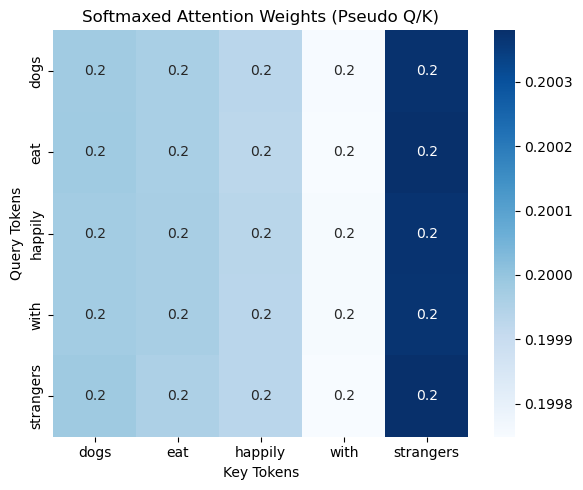

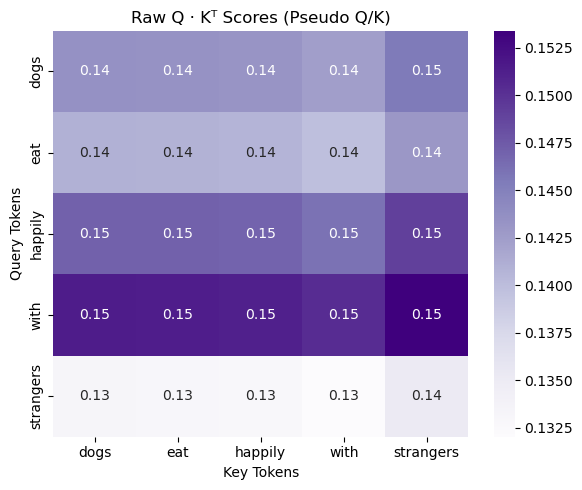

In [167]:
import matplotlib.pyplot as plt
import seaborn as sns

tokens = test_tokens

# Heatmap of softmaxed attention
plt.figure(figsize=(6, 5))
sns.heatmap(attention_weights.squeeze(0).detach().numpy(), annot=True, cmap="Blues", xticklabels=tokens, yticklabels=tokens)
plt.title("Softmaxed Attention Weights (Pseudo Q/K)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.tight_layout()
plt.show()

# (Optional) Heatmap of raw dot products (before softmax)
plt.figure(figsize=(6, 5))
sns.heatmap(raw_scores.squeeze(0).detach().numpy(), annot=True, cmap="Purples", xticklabels=tokens, yticklabels=tokens)
plt.title("Raw Q · Kᵀ Scores (Pseudo Q/K)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.tight_layout()
plt.show()